# Тестирование расширения pg_stl

## 1. Подключение и подготовка данных

In [1]:
! pip install pg8000 statsmodels matplotlib numpy pandas


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pg8000
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import STL

conn = pg8000.connect(
    host="127.0.0.1",
    port=5434,
    database="testdb",
    user="admin",
    password="admin"
)
cur = conn.cursor()
print("✓ Подключение успешно")

✓ Подключение успешно


In [ ]:
# Создаём таблицу с тестовыми данными в БД
cur.execute("DROP TABLE IF EXISTS ts_data")
cur.execute("""
    CREATE TABLE ts_data (
        t       integer PRIMARY KEY,
        value   double precision NOT NULL
    )
""")

np.random.seed(42)
N = 10000
t_arr = np.arange(N)
y_full = 0.5 * t_arr + 10 * np.sin(2 * np.pi * t_arr / 7) + np.random.normal(0, 0.5, N)

rows = [(int(i), float(y_full[i])) for i in range(N)]
cur.executemany("INSERT INTO ts_data VALUES (%s, %s)", rows)
conn.commit()

print(f"✓ Таблица ts_data создана: {N} строк")

✓ Таблица ts_data создана: 10000 строк


## 2. Проверка корректности

Генерируем короткий ряд (100 точек) и сравниваем значения функций.

In [ ]:
n_check = 100
y_check = y_full[:n_check]
nlags = 20

# ACF
cur.execute("""
    SELECT acf_array(array_agg(value ORDER BY t)::double precision[], %s)
    FROM ts_data WHERE t < %s
""", [nlags, n_check])
pg_acf_vals = np.array(cur.fetchone()[0])
sm_acf_vals = acf(y_check, nlags=nlags, fft=False)[1:]

# PACF
cur.execute("""
    SELECT pacf_array(array_agg(value ORDER BY t)::double precision[], %s)
    FROM ts_data WHERE t < %s
""", [nlags, n_check])
pg_pacf_vals = np.array(cur.fetchone()[0])
sm_pacf_vals = pacf(y_check, nlags=nlags, method='ywm')[1:]

# STL
cur.execute("""
    SELECT trend, seasonal, residual
    FROM stl_decompose(
        (SELECT array_agg(value ORDER BY t)::double precision[] FROM ts_data WHERE t < %s),
        7, robust => true
    )
""", [n_check])
row = cur.fetchone()
pg_trend, pg_seasonal, pg_residual = np.array(row[0]), np.array(row[1]), np.array(row[2])

stl_res = STL(y_check, period=7, seasonal=7, robust=True).fit()
sm_trend, sm_seasonal, sm_residual = stl_res.trend, stl_res.seasonal, stl_res.resid

# Вывод
recon = np.max(np.abs(y_check - pg_trend - pg_seasonal - pg_residual))
print("=== Корректность ===")
print(f"ACF  — макс. отклонение от statsmodels: {np.max(np.abs(pg_acf_vals - sm_acf_vals)):.6f}")
print(f"PACF — макс. отклонение от statsmodels: {np.max(np.abs(pg_pacf_vals - sm_pacf_vals)):.6f}")
print(f"STL  — ошибка реконструкции (trend+seasonal+residual=y): {recon:.2e}")

=== Корректность ===
ACF  — макс. отклонение от statsmodels: 0.000000
PACF — макс. отклонение от statsmodels: 0.000000
STL  — ошибка реконструкции (trend+seasonal+residual=y): 0.00e+00


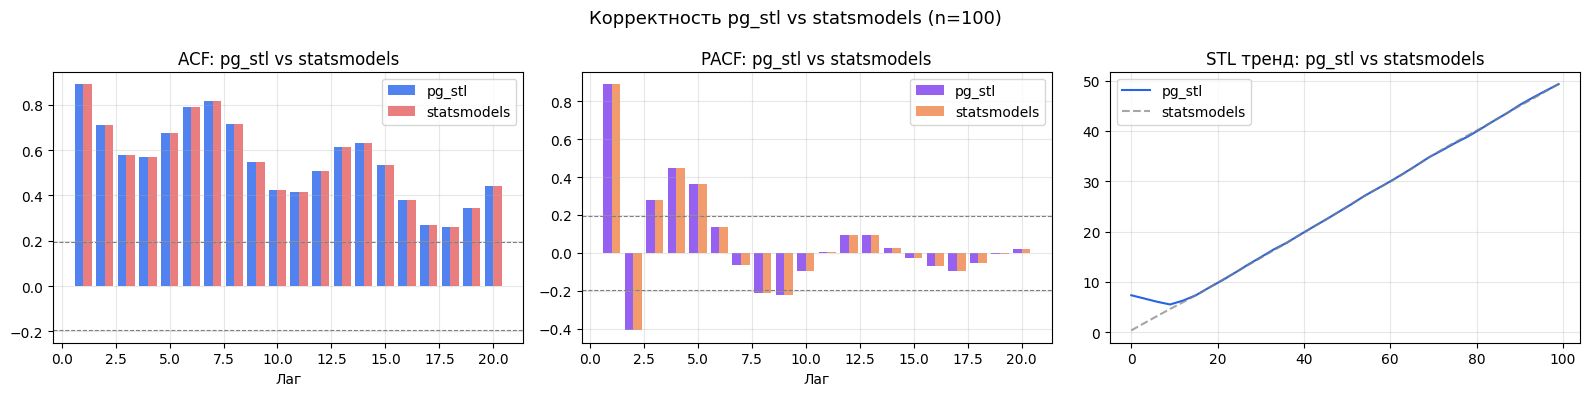

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
lags = np.arange(1, nlags + 1)
ci = 1.96 / np.sqrt(n_check)

# ACF
axes[0].bar(lags - 0.2, pg_acf_vals, 0.4, color='#2563eb', alpha=0.8, label='pg_stl')
axes[0].bar(lags + 0.2, sm_acf_vals, 0.4, color='#dc2626', alpha=0.6, label='statsmodels')
axes[0].axhline(ci, color='gray', linestyle='--', linewidth=0.8)
axes[0].axhline(-ci, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('ACF: pg_stl vs statsmodels')
axes[0].set_xlabel('Лаг')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PACF
axes[1].bar(lags - 0.2, pg_pacf_vals, 0.4, color='#7c3aed', alpha=0.8, label='pg_stl')
axes[1].bar(lags + 0.2, sm_pacf_vals, 0.4, color='#ea580c', alpha=0.6, label='statsmodels')
axes[1].axhline(ci, color='gray', linestyle='--', linewidth=0.8)
axes[1].axhline(-ci, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('PACF: pg_stl vs statsmodels')
axes[1].set_xlabel('Лаг')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# STL тренд
t_plot = np.arange(n_check)
axes[2].plot(t_plot, pg_trend, color='#2563eb', label='pg_stl')
axes[2].plot(t_plot, sm_trend, color='gray', linestyle='--', alpha=0.7, label='statsmodels')
axes[2].set_title('STL тренд: pg_stl vs statsmodels')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Корректность pg_stl vs statsmodels (n=100)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Тестирование производительности

**pg_stl:** вычисление происходит внутри PostgreSQL — данные не покидают базу.  
**Python+statsmodels:** сначала данные выгружаются из БД, затем считаются в Python.

Именно этот сценарий отражает преимущество расширения: **анализ там, где хранятся данные**.

In [ ]:
sizes = [100, 500, 1000, 5000, 10000]
n_runs = 5
nlags_perf = 20

results = {func: {'pg_db': [], 'py_with_export': []} 
           for func in ['ACF', 'PACF', 'STL']}

for size in sizes:
    print(f"\nn = {size}")
    
    # ACF
    # pg_stl: данные в БД, вычисление внутри PostgreSQL
    t0 = time.time()
    for _ in range(n_runs):
        cur.execute("""
            SELECT acf_array(array_agg(value ORDER BY t)::double precision[], %s)
            FROM ts_data WHERE t < %s
        """, [nlags_perf, size])
        cur.fetchone()
    pg_acf_time = (time.time() - t0) / n_runs * 1000
    results['ACF']['pg_db'].append(pg_acf_time)

    # Python: выгрузка + вычисление
    t0 = time.time()
    for _ in range(n_runs):
        cur.execute("SELECT value FROM ts_data WHERE t < %s ORDER BY t", [size])
        data = np.array([r[0] for r in cur.fetchall()])  # выгрузка
        acf(data, nlags=nlags_perf, fft=False)            # вычисление
    py_acf_time = (time.time() - t0) / n_runs * 1000
    results['ACF']['py_with_export'].append(py_acf_time)
    print(f"  ACF:  pg_stl(в БД)={pg_acf_time:.1f}ms  |  Python(выгрузка+расчёт)={py_acf_time:.1f}ms")

    # PACF
    t0 = time.time()
    for _ in range(n_runs):
        cur.execute("""
            SELECT pacf_array(array_agg(value ORDER BY t)::double precision[], %s)
            FROM ts_data WHERE t < %s
        """, [nlags_perf, size])
        cur.fetchone()
    pg_pacf_time = (time.time() - t0) / n_runs * 1000
    results['PACF']['pg_db'].append(pg_pacf_time)

    t0 = time.time()
    for _ in range(n_runs):
        cur.execute("SELECT value FROM ts_data WHERE t < %s ORDER BY t", [size])
        data = np.array([r[0] for r in cur.fetchall()])
        pacf(data, nlags=nlags_perf, method='yw')
    py_pacf_time = (time.time() - t0) / n_runs * 1000
    results['PACF']['py_with_export'].append(py_pacf_time)
    print(f"  PACF: pg_stl(в БД)={pg_pacf_time:.1f}ms  |  Python(выгрузка+расчёт)={py_pacf_time:.1f}ms")

    # STL 
    if size <= 1000:
        t0 = time.time()
        for _ in range(n_runs):
            cur.execute("""
                SELECT trend, seasonal, residual
                FROM stl_decompose(
                    (SELECT array_agg(value ORDER BY t)::double precision[] FROM ts_data WHERE t < %s),
                    7, robust => true
                )
            """, [size])
            cur.fetchone()
        pg_stl_time = (time.time() - t0) / n_runs * 1000
        results['STL']['pg_db'].append(pg_stl_time)

        t0 = time.time()
        for _ in range(n_runs):
            cur.execute("SELECT value FROM ts_data WHERE t < %s ORDER BY t", [size])
            data = np.array([r[0] for r in cur.fetchall()])
            STL(data, period=7, seasonal=7, robust=True).fit()
        py_stl_time = (time.time() - t0) / n_runs * 1000
        results['STL']['py_with_export'].append(py_stl_time)
        print(f"  STL:  pg_stl(в БД)={pg_stl_time:.1f}ms  |  Python(выгрузка+расчёт)={py_stl_time:.1f}ms")


n = 100
  ACF:  pg_stl(в БД)=18.6ms  |  Python(выгрузка+расчёт)=3.6ms
  PACF: pg_stl(в БД)=3.1ms  |  Python(выгрузка+расчёт)=6.8ms
  STL:  pg_stl(в БД)=10.5ms  |  Python(выгрузка+расчёт)=12.2ms

n = 500
  ACF:  pg_stl(в БД)=6.2ms  |  Python(выгрузка+расчёт)=4.1ms
  PACF: pg_stl(в БД)=2.8ms  |  Python(выгрузка+расчёт)=6.3ms
  STL:  pg_stl(в БД)=66.6ms  |  Python(выгрузка+расчёт)=32.6ms

n = 1000
  ACF:  pg_stl(в БД)=3.3ms  |  Python(выгрузка+расчёт)=5.1ms
  PACF: pg_stl(в БД)=2.8ms  |  Python(выгрузка+расчёт)=7.1ms
  STL:  pg_stl(в БД)=219.6ms  |  Python(выгрузка+расчёт)=63.5ms

n = 5000
  ACF:  pg_stl(в БД)=4.6ms  |  Python(выгрузка+расчёт)=73.3ms
  PACF: pg_stl(в БД)=4.5ms  |  Python(выгрузка+расчёт)=22.1ms

n = 10000
  ACF:  pg_stl(в БД)=8.7ms  |  Python(выгрузка+расчёт)=58.0ms
  PACF: pg_stl(в БД)=5.9ms  |  Python(выгрузка+расчёт)=32.3ms


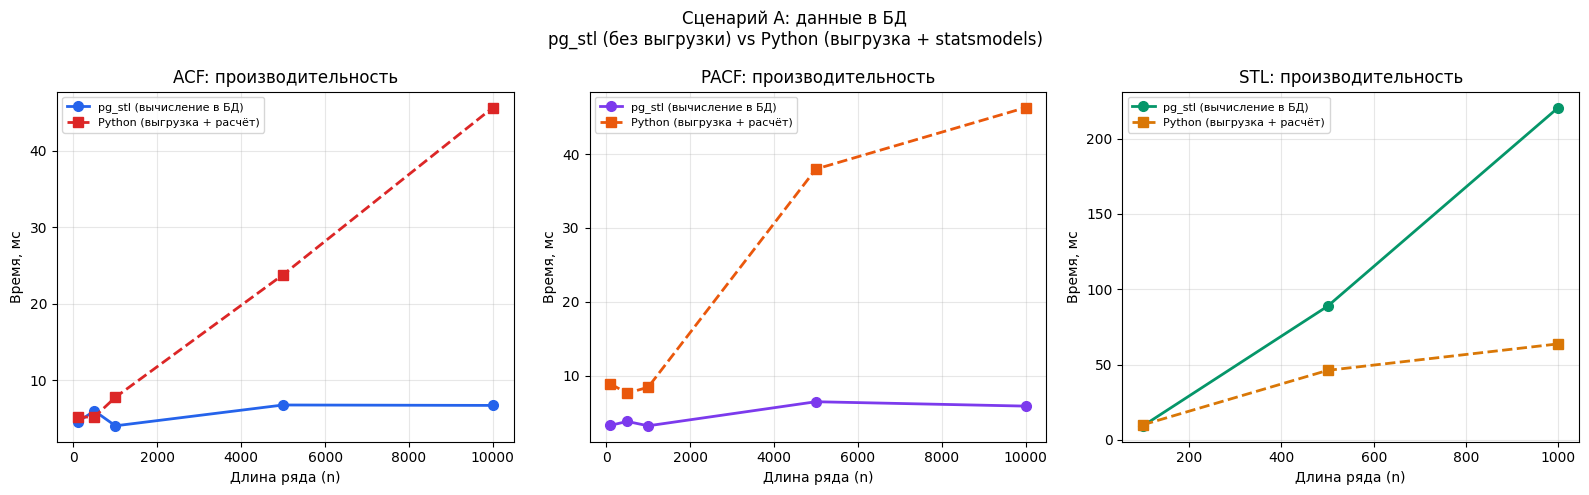

In [ ]:
# Графики производительности
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_pg = ['#2563eb', '#7c3aed', '#059669']
colors_py = ['#dc2626', '#ea580c', '#d97706']
sizes_stl = [s for s in sizes if s <= 1000]

for i, (func, color_pg, color_py) in enumerate(zip(['ACF', 'PACF', 'STL'], colors_pg, colors_py)):
    sz = sizes if func != 'STL' else sizes_stl
    axes[i].plot(sz, results[func]['pg_db'], 'o-', 
                 color=color_pg, linewidth=2, markersize=7, label='pg_stl (вычисление в БД)')
    axes[i].plot(sz, results[func]['py_with_export'], 's--', 
                 color=color_py, linewidth=2, markersize=7, label='Python (выгрузка + расчёт)')
    axes[i].set_title(f'{func}: производительность')
    axes[i].set_xlabel('Длина ряда (n)')
    axes[i].set_ylabel('Время, мс')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Данные в БД\npg_stl (без выгрузки) vs Python (выгрузка + statsmodels)', 
             fontsize=12)
plt.tight_layout()
plt.show()